In [1]:
from river import stream 
from river import datasets
from river import tree, ensemble, forest
from river import metrics
from river import compose, preprocessing, linear_model
from river import feature_extraction
from river import drift
from itertools import islice
from river import base
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metric = metrics.MSE() 
import itertools
from tqdm import tqdm
import pandas as pd
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
from datetime import datetime
import numpy as np
from collections import defaultdict,deque
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# %pip install ipywidgets

In [3]:
# %pip install kagglehub

In [4]:
# Na calym datasecie
# Manhattan        921379
# Queens            58774
# Brooklyn          18071
# Bronx               877
# NaN                 855
# Staten Island        44

In [5]:
# %pip install geopandas shapely pyproj pyogrio --no-cache-dir

In [6]:
#%pip install geopy

In [7]:
path = "airports.csv" 

df_airports = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path
)
path2 = "2008.csv" 
df0 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path2
)

path3="carriers.csv"
df_carriers = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path3
)


In [8]:
us_regions = {
    'South': [
        'TX', 'VA', 'MS', 'FL', 'AR', 'LA', 'OK', 'NC', 
        'KY', 'AL', 'TN', 'MD', 'SC', 'WV', 'GA'
    ],
    'West': [
        'NV', 'CA', 'OR', 'AZ', 'WA', 'UT', 'NM', 'ID', 
        'CO', 'WY', 'HI', 'MT', 'AK'
    ],
    'Midwest': [
        'IN', 'MO', 'IL', 'NE', 'OH', 'MI', 'WI', 'KS', 
        'IA', 'MN', 'SD', 'ND'
    ],
    'Northeast': [
        'NY', 'NH', 'PA', 'RI', 'CT', 'NJ', 'VT', 'ME', 'MA'
    ],
    'Other': [
        'PR', 'VI' 
    ]
}

In [9]:
def previous_flight_features(df):
    df = df.copy()
    
    def hours_transform(time):
        if pd.isna(time):
            return np.nan
        time = int(time)
        hours = time // 100
        mins = time % 100
        t=hours * 60 + mins
        return t

    df['DepTime_mins'] = df['DepTime'].apply(hours_transform)
    df['CRSDepTime_mins'] = df['CRSDepTime'].apply(hours_transform)
    df['CRSArrTime_mins'] = df['CRSArrTime'].apply(hours_transform)
    

    df = df.sort_values(by=['Year', 'Month', 'DayofMonth', 'TailNum', 'DepTime_mins'])
    
    grouping = ['Year', 'Month', 'DayofMonth', 'TailNum']
    
    df['previous_dep_delay'] = df.groupby(grouping)['DepDelay'].shift(1)
    
    df['previous_dep_delay'] = df['previous_dep_delay'].fillna(0)
    
    df['prev_CRSArrTime'] = df.groupby(grouping)['CRSArrTime_mins'].shift(1)
    
    df['scheduled_turnaround'] = df['CRSDepTime_mins'] - df['prev_CRSArrTime']
    
    df['scheduled_turnaround'] = df['scheduled_turnaround'].fillna(60*24)
    
    df = df.drop(columns=['DepTime_mins', 'CRSDepTime_mins', 'CRSArrTime_mins', 'prev_CRSArrTime'])
    df.loc[df['previous_dep_delay'] < 0, 'previous_dep_delay'] = 0
    df.loc[df['DepDelay'] < 0, 'DepDelay'] = 0
    
    return df

df = previous_flight_features(df0)
df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,previous_dep_delay,scheduled_turnaround
465489,2008,1,1,2,714.0,715,925.0,923,9E,5615,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
463104,2008,1,1,2,1657.0,1605,1804.0,1650,9E,4722,...,0,NaN,0,0.0,0.0,22.0,0.0,52.0,0.0,402.0
463589,2008,1,1,2,1829.0,1720,1908.0,1812,9E,4743,...,0,NaN,0,0.0,0.0,0.0,0.0,56.0,52.0,30.0
465147,2008,1,1,2,1935.0,1915,2303.0,2252,9E,5601,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,69.0,63.0
465184,2008,1,1,2,622.0,620,741.0,728,9E,5603,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291645,2008,4,30,3,NaN,1255,NaN,1500,AA,1423,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2297180,2008,4,30,3,NaN,620,NaN,1210,AA,1646,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2300746,2008,4,30,3,NaN,1350,NaN,1845,AA,1774,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2343984,2008,4,30,3,NaN,1850,NaN,2323,CO,732,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0


In [10]:
df["previous_dep_delay"].describe()

count    2.389217e+06
mean     9.095967e+00
std      2.889764e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      2.467000e+03
Name: previous_dep_delay, dtype: float64

In [11]:
df["scheduled_turnaround"].describe()

count    2.389217e+06
mean     3.760064e+02
std      5.919194e+02
min     -1.424000e+03
25%      3.100000e+01
50%      5.000000e+01
75%      3.020000e+02
max      1.440000e+03
Name: scheduled_turnaround, dtype: float64

In [12]:
def airline_stream(df):
    
    columns_to_drop = [
        'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay','LateAircraftDelay',
        'TaxiIn', 'TaxiOut', 'ArrDelay', 'DepDelay',  
        'AirTime', 'ActualElapsedTime', 'UniqueCarrier', 
        'ArrTime','Year',
        'CancellationCode','Diverted','Cancelled',
        'FlightNum','TailNum',
        'Origin','Dest'
        
        
    ]
    
    for row in df:
        x = dict(row)
        is_cancelled = int(x.get('Cancelled', 0)) == 1
        is_diverted = int(x.get('Diverted', 0)) == 1
        if is_cancelled or is_diverted:
            continue
            
        y = x.get('ArrDelay')
        for col in columns_to_drop:
            x.pop(col, None)
        
        yield x, y

In [13]:
df_m = df.merge(
    df_airports[['iata', 'state','lat','long']], 
    left_on='Origin', 
    right_on='iata', 
    how='inner'
)
df_m= df_m.rename(columns={'state': 'origin_state','lat':'origin_lat','long':'origin_long'}).drop(columns='iata')


In [14]:
df_merged = df_m.merge(
    df_airports[['iata', 'state','lat','long']], 
    left_on='Dest', 
    right_on='iata', 
    how='inner'
)
df_merged = df_merged.rename(columns={'state': 'dest_state','lat':'dest_lat','long':'dest_long'}).drop(columns='iata')


In [15]:
df_merged.head(5)

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,SecurityDelay,LateAircraftDelay,previous_dep_delay,scheduled_turnaround,origin_state,origin_lat,origin_long,dest_state,dest_lat,dest_long
0,2008,1,1,2,714.0,715,925.0,923,9E,5615,...,NaN,NaN,0.0,1440.0,AR,36.281869,-94.306811,MN,44.880547,-93.216922
1,2008,1,1,2,1657.0,1605,1804.0,1650,9E,4722,...,0.0,52.0,0.0,402.0,MN,44.880547,-93.216922,MN,43.908826,-92.497987
2,2008,1,1,2,1829.0,1720,1908.0,1812,9E,4743,...,0.0,56.0,52.0,30.0,MN,43.908826,-92.497987,MN,44.880547,-93.216922
3,2008,1,1,2,1935.0,1915,2303.0,2252,9E,5601,...,NaN,NaN,69.0,63.0,MN,44.880547,-93.216922,NC,36.097747,-79.937297
4,2008,1,1,2,622.0,620,741.0,728,9E,5603,...,NaN,NaN,0.0,1440.0,IA,41.534933,-93.660682,MN,44.880547,-93.216922


In [16]:
rows = df_merged.to_dict(orient='records')
data = airline_stream(rows)

full_stream=data
x, y = next(data)
print(x)
print(y)


{'Month': 1, 'DayofMonth': 1, 'DayOfWeek': 2, 'DepTime': 714.0, 'CRSDepTime': 715, 'CRSArrTime': 923, 'CRSElapsedTime': 128.0, 'Distance': 596, 'previous_dep_delay': 0.0, 'scheduled_turnaround': 1440.0, 'origin_state': 'AR', 'origin_lat': 36.28186944, 'origin_long': -94.30681111, 'dest_state': 'MN', 'dest_lat': 44.88054694, 'dest_long': -93.2169225}
2.0


In [17]:
x, y = next(iter(data))
x

{'Month': 1,
 'DayofMonth': 1,
 'DayOfWeek': 2,
 'DepTime': 1657.0,
 'CRSDepTime': 1605,
 'CRSArrTime': 1650,
 'CRSElapsedTime': 45.0,
 'Distance': 76,
 'previous_dep_delay': 0.0,
 'scheduled_turnaround': 402.0,
 'origin_state': 'MN',
 'origin_lat': 44.88054694,
 'origin_long': -93.2169225,
 'dest_state': 'MN',
 'dest_lat': 43.90882639,
 'dest_long': -92.49798722}

In [18]:
class FeatureDistrict(base.Transformer):
    
    def get_region(self, state_code):
        for region, states in us_regions.items():
            if state_code in states:
                return region
        return 'none'
      
    def transform_one(self, x):
        x = x.copy()
        
        pickup_d = self.get_region(x["origin_state"])
        dropoff_d = self.get_region(x["dest_state"])

        x["pickup_district"] = pickup_d
        x["dropoff_district"] = dropoff_d

        x["within_district"] = int(
            pickup_d == dropoff_d and pickup_d != "Other" and pickup_d !="none" 
        )

        x["is_weekend"] = int(x["DayOfWeek"] > 5)
        
        month = int(x["Month"])
        day = int(x["DayofMonth"])
        h=int(x["CRSDepTime"]//100)
        min=x["CRSDepTime"]
        x["timestamp"] = datetime(2008,month, day,h)
        
        columns_to_drop=["Month","DayofMonth","DayOfWeek","origin_state","dest_state","DepTime"]
        for col in columns_to_drop:
            x.pop(col, None)
            

        return x

In [19]:
transformer = FeatureDistrict()
x_2 = transformer.transform_one(x)
x_2

{'CRSDepTime': 1605,
 'CRSArrTime': 1650,
 'CRSElapsedTime': 45.0,
 'Distance': 76,
 'previous_dep_delay': 0.0,
 'scheduled_turnaround': 402.0,
 'origin_lat': 44.88054694,
 'origin_long': -93.2169225,
 'dest_lat': 43.90882639,
 'dest_long': -92.49798722,
 'pickup_district': 'Midwest',
 'dropoff_district': 'Midwest',
 'within_district': 1,
 'is_weekend': 0,
 'timestamp': datetime.datetime(2008, 1, 1, 16, 0)}

In [20]:

def createShadow():
     return forest.ARFRegressor(n_models=12, seed=0)


In [21]:
def models_dist(district):
    #scaler = preprocessing.StandardScaler()
    if district == "South":
        #model = forest.ARFRegressor(n_models=10, seed=0)
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "West":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "Midwest":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
         #model = forest.ARFRegressor(n_models=13, seed=0)
    elif district == "Northeast":
        model = ensemble.SRPRegressor(n_models=13, seed=0)
    elif district == "Global":
        model = forest.ARFRegressor(n_models=10, seed=0)
    return model


districts = ["South", "West","Midwest", "Northeast", "Global"]
models = {d: models_dist(d) for d in districts}
shadow_models = {d: None for d in districts}

In [22]:
# 



In [23]:
# distribution_detectors

In [24]:
# x, y = next(iter(data))

# timestamp = x["pickup_datetime"]

# x = transformer.transform_one(x)
# if x["within_district"] == 1:
#     district = x["pickup_district"]
# else:
#     district="Global"
# x.pop("pickup_district",None)
# x.pop("pickup_district",None)
# x


In [25]:
def built_centroid(X):
    if len(X) == 0:
        return None
    return np.mean(X, axis=0)
    
def centroid_distance(c1, c2):
    return np.linalg.norm(c1 - c2) #sprawdzic inna Mahalanobis?
centroid_windows = []
centroid_drift_log = defaultdict(list)
centroid_adwin = {d: drift.ADWIN(delta=0.007) for d in districts}

daily_errors = defaultdict(lambda: defaultdict(list))

In [26]:
local_counts = {d: 0 for d in districts}

#zmienne do rmse
window_size = 50  
error_windows = defaultdict(list)
window_rmse_series = defaultdict(lambda: defaultdict(list))
time_series = defaultdict(list)

#zmienne do dryftu 
drift_timestamps = {d: [] for d in districts}
drift_instances = {d: [] for d in districts}  

kswin_timestamps = {d: [] for d in districts}
kswin_instances = {d: [] for d in districts}  

# window_size = 200 
# error_series = {d: [] for d in districts}     

# window_error = {d: [] for d in districts}
# window=100
# time_series = {d: [] for d in districts}

# drift_dist_t={d: [] for d in districts}



In [27]:
configs = {
    "South": {"window_size": 200, "stat_size": 50, "alpha": 0.001},
    "West": {"window_size": 200, "stat_size": 50, "alpha": 0.001},
    "Midwest": {"window_size": 100, "stat_size": 30, "alpha": 0.0009},
    "Northeast": {"window_size": 300, "stat_size": 20, "alpha": 0.001},

    "Global": {"window_size": 100, "stat_size": 30, "alpha": 0.01}

}


In [28]:
s=2000000 #5 min dla 300000 sample

transformer = FeatureDistrict()
stream = itertools.islice(full_stream, s)

In [29]:
WARMUP_DAYS      = 10      
# ERROR_WINDOW    = 500     
ADWIN_DELTA      = 0.0001    
PH_MIN_INSTANCES = 30      
PH_THRESHOLD     = 0.01     
PH_ALPHA         = 0.999    


In [30]:
adwin_configs_2 = {
    "South": {"delta": 0.01},    
    "West": {"delta": 0.5},      
    "Midwest": {"delta": 0.1},  
    "Northeast": {"delta": 0.002}, 
    "Global": {"delta": 0.001}      
}
adwin_configs = {
    "South": {"delta": 0.0005},    
    "West": {"delta": 0.001},      
    "Midwest": {"delta": 0.001},  
    "Northeast": {"delta": 0.0002}, 
    "Global": {"delta": 0.0001}      
}
drift_detectors = {
    d: drift.ADWIN(delta=adwin_configs[d]["delta"])
    for d in districts
}
centroid_adwin= {
    d: drift.ADWIN(delta=adwin_configs_2[d]["delta"])
    for d in districts
}
centroid_adwin_drift_log = {d: [] for d in districts}

In [31]:
# drift_detectors  = {d: drift.ADWIN(delta=ADWIN_DELTA) for d in districts}
error_windows    = defaultdict(list)             
window_rmse_series = defaultdict(lambda: defaultdict(list))

drift_timestamps  = {d: [] for d in districts}
drift_instances   = {d: [] for d in districts}


centroid_warmup   = defaultdict(list)   
centroid_ref      = {}               


daily_feature_buf = defaultdict(lambda: defaultdict(list)) 
centroid_ph       = {
    d: drift.PageHinkley(min_instances=PH_MIN_INSTANCES,
                         threshold=PH_THRESHOLD,
                         alpha=PH_ALPHA)
    for d in districts
}
centroid_drift_log = {d: [] for d in districts}


daily_errors  = defaultdict(lambda: defaultdict(list))
local_counts  = {d: 0 for d in districts}
local_counts_drift  = {d: 0 for d in districts}
shadow_models = {d: None for d in districts}

first_date    = {}          
count_samples=0

In [32]:
# error_window_config = {
#     "South": 2000,
#     "West": 2000,
#     "Midwest": 350,
#     "Northeast": 200,
#     "Global": 1000
# }

In [33]:
error_window_config = {
    "South": 4000,
    "West": 4000,
    "Midwest": 700,
    "Northeast": 400,
    "Global": 2000
}

In [34]:
start_time = time.time()
for x,y in stream:
# for x, y in tqdm(stream, total=s, desc="Done"):

    x = transformer.transform_one(x)
    timestamp = pd.to_datetime(x["timestamp"])
    date = timestamp.date()
    x.pop("timestamp",None)
    if x["within_district"] == 1:
        district = x["pickup_district"]
    else:
        district="Global"
    x.pop("pickup_district",None)
    x.pop("dropoff_district",None)
    model  = models[district]
    y_pred = model.predict_one(x)
    count_samples+=1
    if count_samples % 10000 == 0:

        elapsed = time.time() - start_time

        progress = count_samples / s

        print(
            f"DONE: {count_samples:,}/{s:,} "
            f"({progress*100:.1f}%) | "
            f"Elapsed: {elapsed/60:.2f} min "
        )
    ERROR_WINDOW=error_window_config[district]
    local_counts[district] += 1
    local_counts_drift[district]+=1
    instance_count = local_counts[district]
    
    if district not in first_date:
        first_date[district] = date

    feature_vec = np.array(list(x.values()), dtype=float)

    # Ref centroid 
    days_elapsed = (date - first_date[district]).days
    in_warmup    = days_elapsed < WARMUP_DAYS

    if in_warmup:
        centroid_warmup[district].append(feature_vec)
    else:
        
        if district not in centroid_ref and centroid_warmup[district]:
            centroid_ref[district] = built_centroid(centroid_warmup[district])
            print(f"[Centroid] Ref built for {district} "
                  f"({len(centroid_warmup[district])} samples)")


        daily_feature_buf[district][date].append(feature_vec)

        # Na koniec każdego dnia (pierwsze trafienie w NOWY dzień) 
        # policz centroid poprzedniego dnia i podaj do PH
        # → iterujemy po dniach wcześniejszych niż dziś, które nie były jeszcze przetworzone
        processed_dates = getattr(centroid_ph[district], "_processed_dates", set())
        for past_date, vecs in list(daily_feature_buf[district].items()):
            if past_date < date and past_date not in processed_dates:
                if district in centroid_ref:
                    daily_c   = built_centroid(vecs)
                    dist_val  = centroid_distance(daily_c, centroid_ref[district])
                    centroid_ph[district].update(dist_val)
                    centroid_adwin[district].update(dist_val)

                    if centroid_ph[district].drift_detected:
                        print(f"[Centroid DRIFT] {district} | dzień: {past_date} "
                              f"| dist: {dist_val:.4f} | instance: {instance_count}")
                        centroid_drift_log[district].append({
                            "date":     past_date,
                            "instance": instance_count,
                            "distance": dist_val,
                        })
                    if centroid_adwin[district].drift_detected:
                        print(f"[Centroid ADWIN DRIFT] {district} | dzień: {past_date} "
                              f"| dist: {dist_val:.4f} | instance: {instance_count}")
                        centroid_adwin_drift_log[district].append({
                            "date":     past_date,
                            "instance": instance_count,
                            "distance": dist_val,
                        })

                    processed_dates.add(past_date)
                    centroid_ph[district]._processed_dates = processed_dates

    
    # model = models[district]
    
    # y_pred = model.predict_one(x)
    # local_counts[district] += 1
    # instanceCount = local_counts[district]

    if y_pred is not None:
        if y_pred < 0:
            y_pred = 0

        mae = abs(y_pred - y)
        daily_errors[district][date].append(mae)

        sq_err = (y_pred - y) ** 2
        error_windows[district].append(sq_err)
        if len(error_windows[district]) > ERROR_WINDOW:
            error_windows[district].pop(0)

        if len(error_windows[district]) == ERROR_WINDOW:
            rmse = np.sqrt(sum(error_windows[district]) / ERROR_WINDOW)
            window_rmse_series[district][timestamp].append(rmse)

    
            drift_detectors[district].update(rmse)

            if local_counts_drift[district] > 10000 and drift_detectors[district].drift_detected:
                local_counts_drift[district]=0
                print(f"[Error DRIFT] {district} | instance: {instance_count} "
                      f"| RMSE: {rmse:.4f}")
                drift_instances[district].append(instance_count)
                drift_timestamps[district].append(timestamp)


    model.learn_one(x, y)
                
    

    

DONE: 10,000/2,000,000 (0.5%) | Elapsed: 0.24 min 
DONE: 20,000/2,000,000 (1.0%) | Elapsed: 0.53 min 
DONE: 30,000/2,000,000 (1.5%) | Elapsed: 0.84 min 
DONE: 40,000/2,000,000 (2.0%) | Elapsed: 1.17 min 
[Error DRIFT] West | instance: 10207 | RMSE: 30.1109
[Error DRIFT] South | instance: 10175 | RMSE: 26.9469
DONE: 50,000/2,000,000 (2.5%) | Elapsed: 1.48 min 
DONE: 60,000/2,000,000 (3.0%) | Elapsed: 1.80 min 
DONE: 70,000/2,000,000 (3.5%) | Elapsed: 2.13 min 
DONE: 80,000/2,000,000 (4.0%) | Elapsed: 2.47 min 
DONE: 90,000/2,000,000 (4.5%) | Elapsed: 2.82 min 
[Error DRIFT] West | instance: 20287 | RMSE: 51.6093
[Error DRIFT] South | instance: 20191 | RMSE: 24.3784
DONE: 100,000/2,000,000 (5.0%) | Elapsed: 3.18 min 
DONE: 110,000/2,000,000 (5.5%) | Elapsed: 3.54 min 
DONE: 120,000/2,000,000 (6.0%) | Elapsed: 3.94 min 
DONE: 130,000/2,000,000 (6.5%) | Elapsed: 4.33 min 
[Error DRIFT] South | instance: 30559 | RMSE: 25.3852
[Error DRIFT] West | instance: 30367 | RMSE: 29.6396
DONE: 140,00

In [35]:
# df = pd.DataFrame([
#         (t, rmse)
#         for t, values in window_rmse_series[].items()
#         for rmse in values
#     ], columns=["time", "rmse"])
# df

In [36]:
centroid_adwin_drift_log

{'South': [], 'West': [], 'Midwest': [], 'Northeast': [], 'Global': []}

In [41]:
centroid_drift_log["South"]

[{'date': datetime.date(2008, 2, 9),
  'instance': 165500,
  'distance': np.float64(93.78342486684505)},
 {'date': datetime.date(2008, 3, 10),
  'instance': 292058,
  'distance': np.float64(13.040435663832756)},
 {'date': datetime.date(2008, 4, 9),
  'instance': 421148,
  'distance': np.float64(27.787038377221602)}]

In [42]:
centroid_drift_log["West"]

[{'date': datetime.date(2008, 2, 9),
  'instance': 169012,
  'distance': np.float64(72.1072825451861)},
 {'date': datetime.date(2008, 3, 10),
  'instance': 296897,
  'distance': np.float64(22.439550624142075)},
 {'date': datetime.date(2008, 4, 9),
  'instance': 423492,
  'distance': np.float64(24.698167153176815)}]

In [45]:
centroid_drift_log["Global"]

[{'date': datetime.date(2008, 2, 9),
  'instance': 352723,
  'distance': np.float64(104.37408437807622)},
 {'date': datetime.date(2008, 3, 10),
  'instance': 624291,
  'distance': np.float64(18.60080688296711)},
 {'date': datetime.date(2008, 4, 9),
  'instance': 903739,
  'distance': np.float64(21.40503092002591)}]

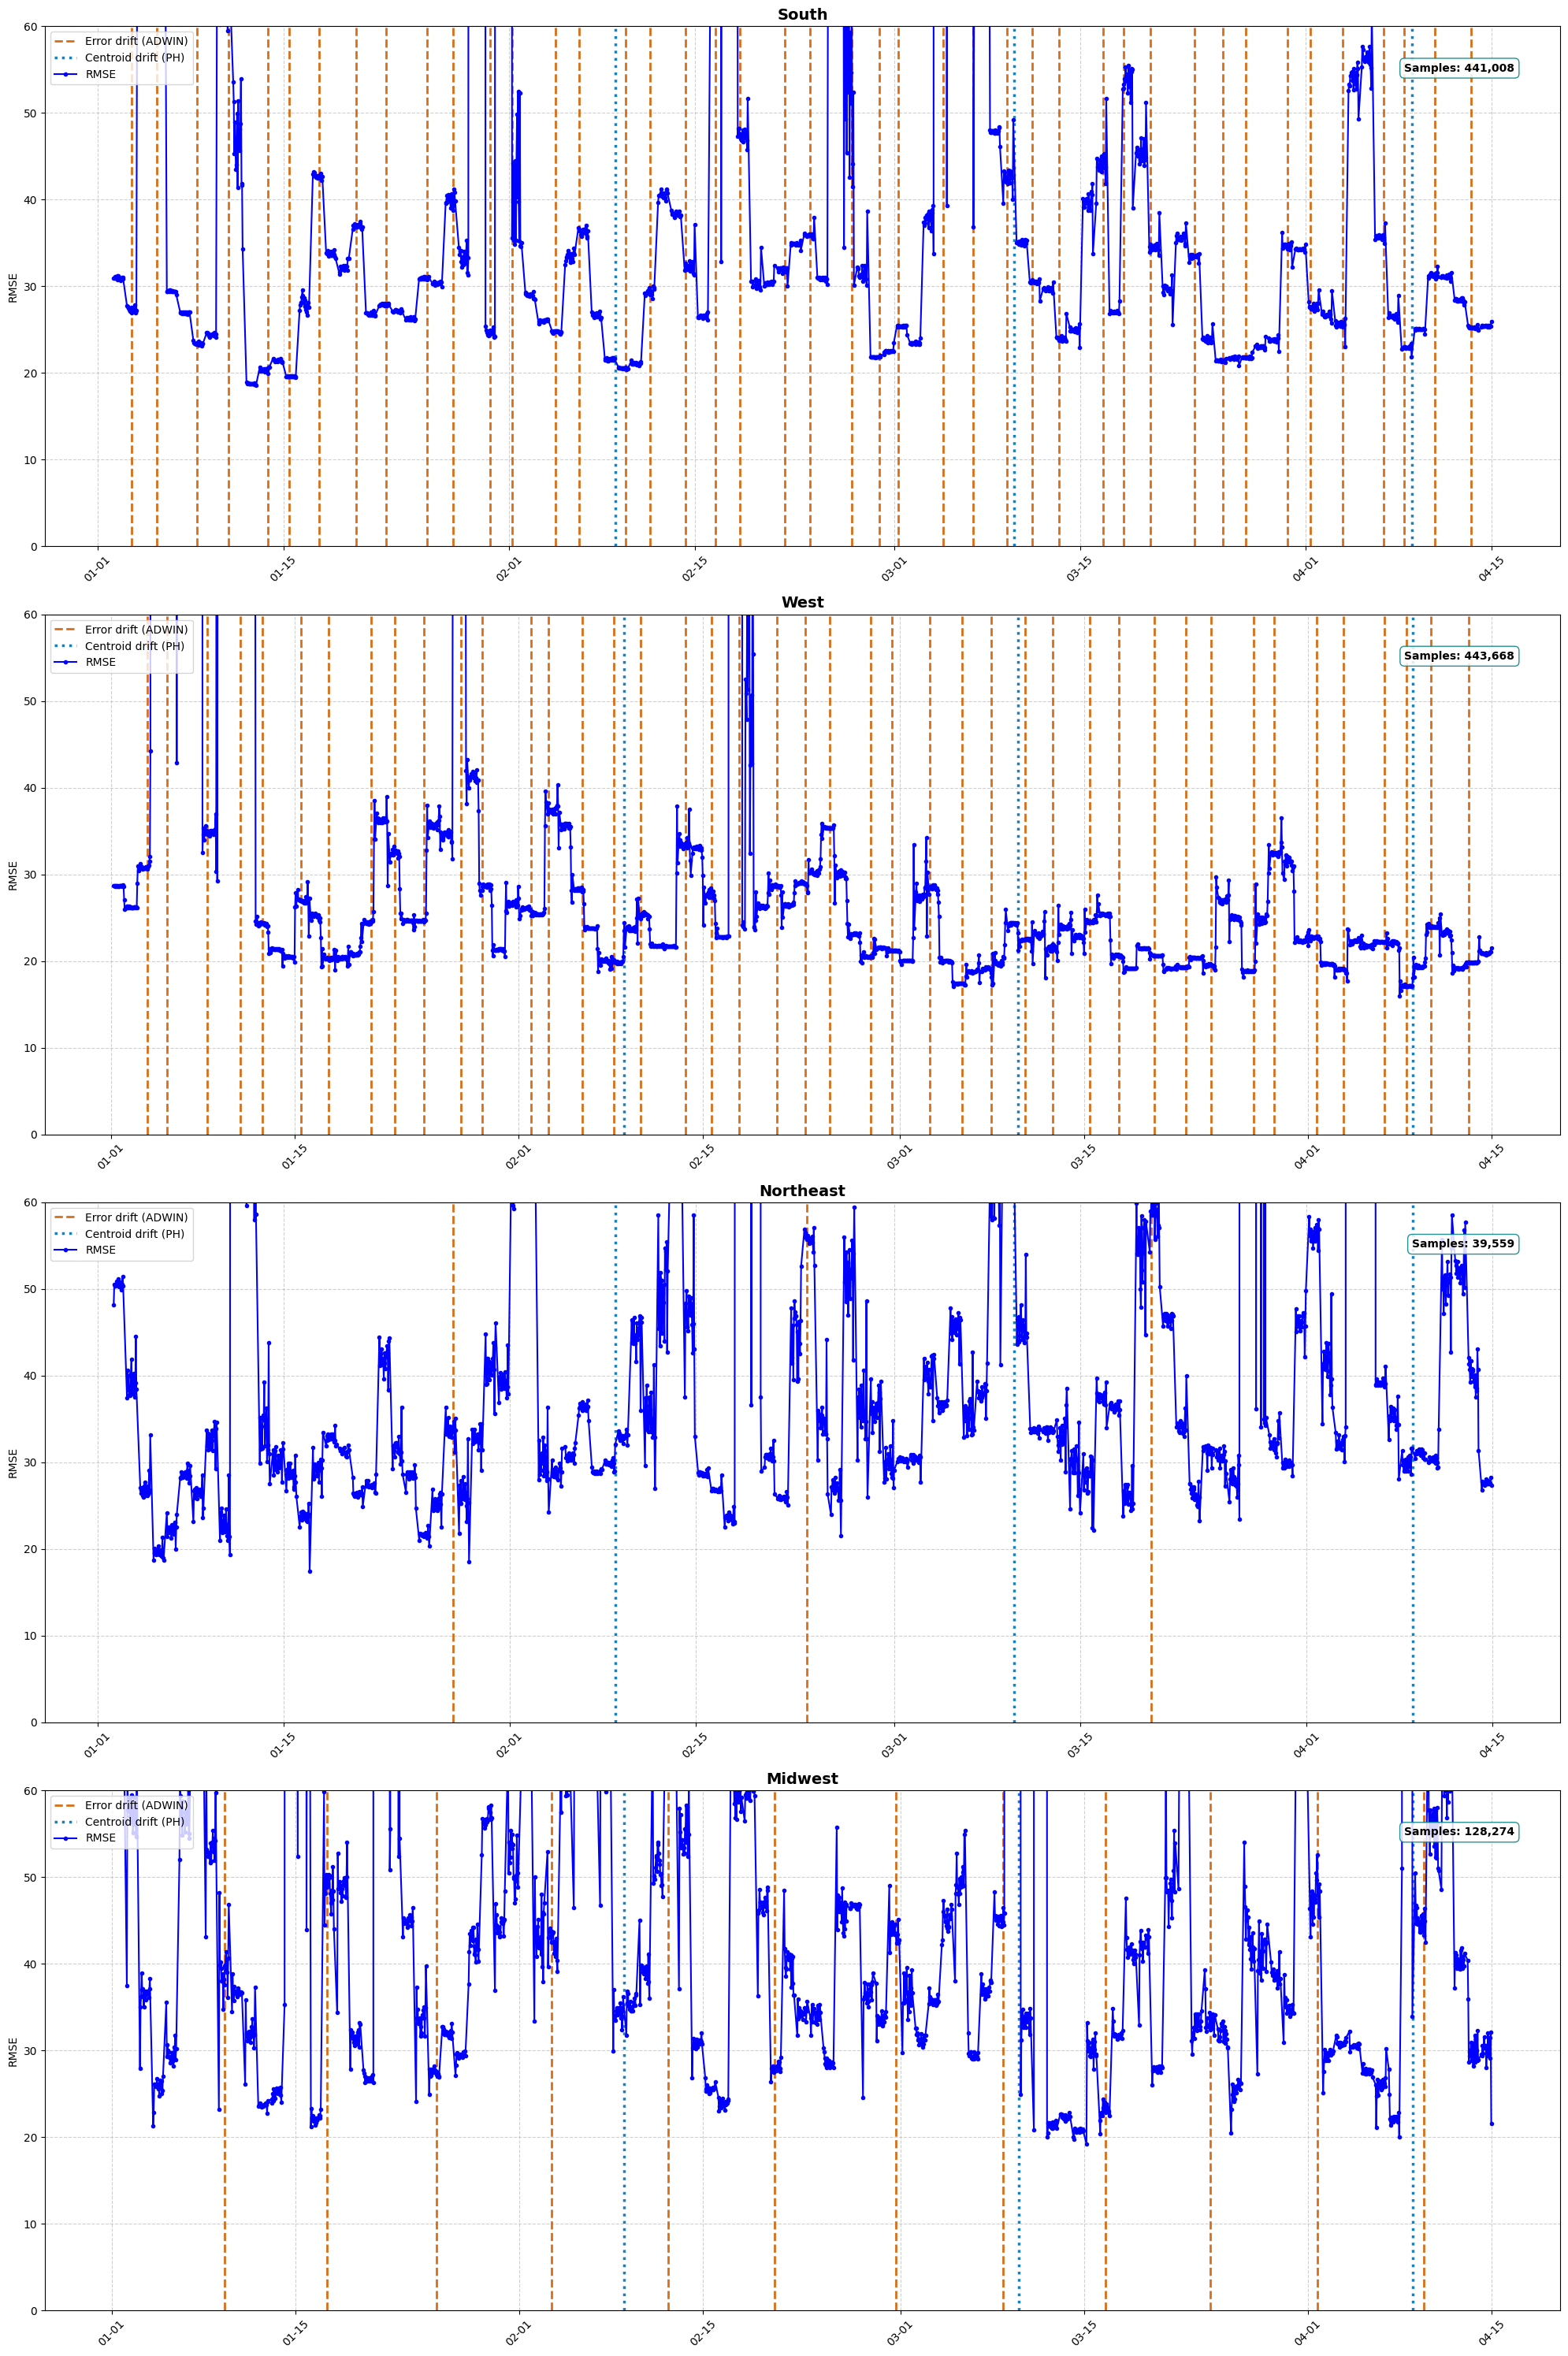

In [40]:


district_list = ["South", "West", "Northeast", "Midwest"]


fig, axes = plt.subplots(4, 1, figsize=(20, 30), sharex=False)
axes = axes.flatten()

for ax, dist in zip(axes, district_list):

    dist_data = window_rmse_series.get(dist, {})
    
    if not dist_data:
        ax.set_title(f"{dist} (Brak danych)", fontsize=14, fontweight='bold')
        continue
        
    timestamps = sorted(dist_data.keys())
    
    mean_rmses = [np.mean(dist_data[ts]) for ts in timestamps]
    count = local_counts.get(dist, 0)

    ax.text(
        0.97,
        0.93,
        f"Samples: {count:,}",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            alpha=0.85,
            edgecolor='#008080'
        ),
        fontsize=10,
        fontweight='bold'
    )


    if dist in drift_timestamps:

        for i, t in enumerate(drift_timestamps[dist]):

            ax.axvline(
                pd.to_datetime(t),
                color="#D55E00",
                linestyle='--',
                linewidth=2,
                alpha=0.9,
                label="Error drift (ADWIN)" if i == 0 else ""
            )

    if dist in centroid_drift_log:

        for i, drift_event in enumerate(centroid_drift_log[dist]):

            drift_date = pd.to_datetime(drift_event["date"])

            ax.axvline(
                drift_date,
                color="#0072B2",
                linestyle=':',
                linewidth=2.5,
                alpha=0.9,
                label="Centroid drift (PH)" if i == 0 else ""
            )
    if dist in centroid_adwin_drift_log:

        for i, drift_event in enumerate(centroid_adwin_drift_log[dist]):

            drift_date = pd.to_datetime(drift_event["date"])

            ax.axvline(
                drift_date,
                color="green",
                linestyle=':',
                linewidth=2.5,
                alpha=0.9,
                label="Centroid ADWIN drift (PH)" if i == 0 else ""
            )


    ax.set_ylim(0, 60)

    ax.plot(timestamps, mean_rmses, linestyle='-', marker='.', color='b',label='RMSE')
    
    ax.set_title(dist, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel('RMSE')
    ax.legend(
        loc='upper left',
        frameon=True,
        facecolor='white'
    )

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    "district_drift_final.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:

# dist = "Global"
# fig, ax = plt.subplots(figsize=(12, 6))


# errors = day_rmse.get(dist, [])
# times = time_series.get(dist, [])

# df_plot = pd.DataFrame({
#     "time": times,
#     "error": errors
# }).sort_values("time")

# time_plot = df_plot["time"]
# error_plot = df_plot["error"]


# line_ref = ax.plot(
#     time_plot,
#     error_plot,
#     label=f"Daily error {dist}",
#     linewidth=2
# )[0]

# color = line_ref.get_color()

# count = local_counts.get(dist, 0) 

# # Pole tekstowe z liczbą próbek
# ax.text(0.95, 0.90, f"Samples: {count:,}", 
#         transform=ax.transAxes, 
#         verticalalignment='top', 
#         horizontalalignment='right',
#         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor=color),
#         fontsize=11, fontweight='bold', color='#333333')


# if dist in drift_timestamps:
#     for i, t in enumerate(drift_timestamps[dist]):
#         lbl = "Drift detected" if i == 0 else ""
#         ax.axvline(
#             pd.to_datetime(t),
#             color="red", 
#             linestyle='--',
#             linewidth=2,
#             alpha=0.7,
#             label=lbl
#         )

# if dist in centroid_drift_log:
#     for i, t in enumerate(centroid_drift_log[dist]):
#         lbl = "Distribution shift detected" if i == 0 else ""
        
#         drift_time = pd.to_datetime(t["time"]) 
        
#         ax.axvline(
#             x=drift_time,
#             color="#FFE5B4", 
#             linestyle='--',
#             linewidth=2,
#             alpha=0.7,
#             label=lbl
#         )


# ax.set_title(dist.upper(), fontsize=15, fontweight='bold', pad=15)
# ax.set_ylim(0, 100)
# ax.set_ylabel("RMSE", fontsize=12)

# ax.grid(True, which='major', linestyle='--', alpha=0.4, color='gray')

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# ax.tick_params(axis='x', rotation=45, labelsize=10)


# if (dist in drift_timestamps) or (dist in centroid_drift_log):
#     ax.legend(loc='upper left', frameon=True, facecolor='white')

# plt.tight_layout()

# plt.savefig('Airlines_Global.png', dpi=300, bbox_inches='tight') 
# plt.show()